## Project Overview

This project focuses on classifying pet images into different cat and dog breeds using a deep learning image classification model.
A ResNet50 model pretrained on ImageNet is used as a feature extractor, with a custom classification layer trained to recognize 16 pet categories.
The project demonstrates an end-to-end computer vision workflow, including:
1.Image preprocessing and resizing
2.Label encoding
3.Train, validation, and test dataset splitting
4.Data augmentation
5.Transfer learning with ResNet50
6.Model training and validation
7.Performance evaluation
8.Prediction on unseen test images

## Objective
The objective is to build a multiclass image classification model capable of identifying the breed/category represented in a pet image.

## Model Approach
Instead of training a deep convolutional neural network from scratch, the project uses "transfer learning". The convolutional base of ResNet50 is initialized with ImageNet pretrained weights and kept frozen, while a new classification head is trained for the 16 target classes.


In [38]:
# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as image

# File and path handling
import os
import glob

# Deep learning
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras import Input, Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import RandomFlip, RandomRotation, Dense, Dropout
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

# Dataset splitting
from sklearn.model_selection import train_test_split

#Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix

# 1. Dataset Set-Up
The images are stored in the images directory. Each image filename contains the corresponding pet breed/category, which is extracted and used as the target label for classification.
The dataset contains images belonging to 16 pet categories, including both cat and dog breeds.

In [4]:
images_fp = './images'

In [5]:
image_names = [os.path.basename(file) for file in glob.glob(os.path.join(images_fp, '*.jpg'))]

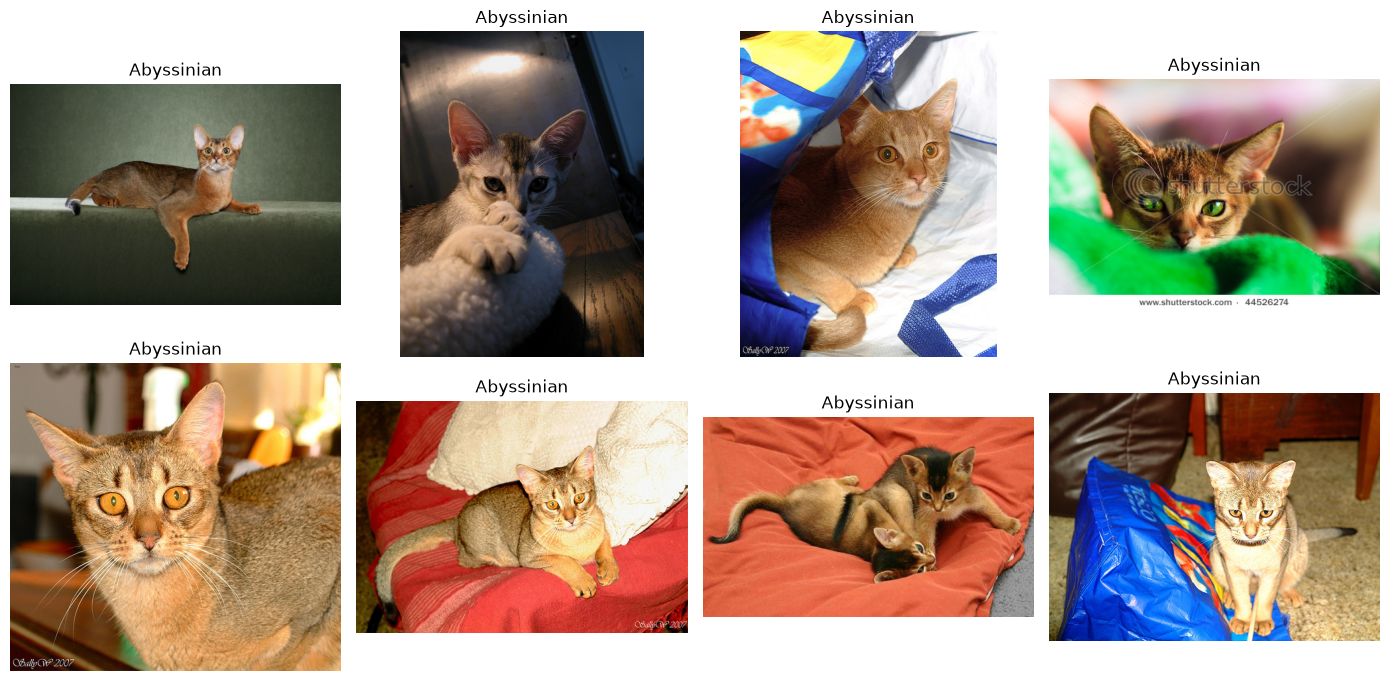

In [6]:
# DataSet Preview
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for ax, name in zip(axes.flat, image_names[:8]):
    img = image.imread(os.path.join(images_fp, name))
    ax.imshow(img)
    ax.set_title(' '.join(name.split('_')[:-1]))
    ax.axis('off')

plt.tight_layout()
plt.show()

# 2. Label Extraction and Encoding

In [8]:
labels = [' '.join(name.split('_')[:-1:]) for name in image_names]

In [9]:
#converting lables into number codes
def label_encode(label) :
        if label == 'Abyssinian' : return 0
        elif label == 'Bengal' : return 1
        elif label == 'Birman' : return 2
        elif label == 'Bombay' : return 3
        elif label == 'British Shorthair' : return 4
        elif label == 'Egyptian Mau' : return 5
        elif label == 'american bulldog' : return 6
        elif label == 'american pit bull terrier' : return 7
        elif label == 'basset hound' : return 8
        elif label == 'beagle' : return 9
        elif label == 'boxer' : return 10
        elif label == 'chihuahua' : return 11
        elif label == 'english cocker spaniel' : return 12
        elif label == 'english setter' : return 13
        elif label == 'german shorthaired' : return 14
        elif label == 'great pyrenees' : return 15
        return None

# 3. Image Preprocessing

In [11]:
features = []
labels = []
IMAGE_SIZE = (224,224)

In [12]:
for name in image_names:
    label = ' '.join(name.split('_')[:-1:])
    label_encoded = label_encode(label)
    if label_encoded != None:
        img = load_img(os.path.join(images_fp, name))
        #if image is lesser that (224,224) then it will add padding
        img = tf.image.resize_with_pad(img_to_array(img, dtype = 'uint8'), *IMAGE_SIZE)
        image = np.array(img)
        features.append(image)
        labels.append(label_encoded)

In [13]:
features_array = np.array(features, dtype = np.uint8)
labels_array = np.array(labels)

# 4. One hot encoding + Dataset Splitting

In [15]:
labels_one_hot = pd.get_dummies(labels_array)

In [16]:
#split the dataset into three parts : 1-training data 2-validation data 3-testing data
#training data - 60% validation data - 20% testing data - 20%

In [17]:
X_train, X_test, y_train, y_test = train_test_split(features_array, labels_one_hot, test_size = 0.2, random_state = 42)

In [18]:
#training data - 60% | validation data - 20% 
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.25, random_state = 1)

# 5. Data Augmentation and Transfer Learning
Transfer Learning with ResNet50
A ResNet50 network pretrained on ImageNet is used as the feature extraction backbone.
The pretrained convolutional layers are kept frozen, allowing the model to reuse visual features learned from the large ImageNet dataset. A new classification head is then trained to classify the images into the 16 target categories.

In [20]:
data_augmentation = Sequential([RandomFlip("horizontal_and_vertical"), RandomRotation(0.2)])
prediction_layers = Dense(16, activation = 'softmax')

In [21]:
resnet_model = ResNet50(include_top = False, pooling = 'avg', weights = 'imagenet')
resnet_model.trainable = False

In [22]:
#Build Model
inputs = Input(shape = (224,224,3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = resnet_model(x, training = False)
x = Dropout(0.2)(x)
outputs = prediction_layers(x)
model = Model(inputs, outputs)
model.compile(optimizer = Adam(), loss = CategoricalCrossentropy(), metrics = ['accuracy'])
model_history = model.fit(x = X_train, y = y_train, validation_data = (X_val, y_val), epochs = 10)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 261s 4s/step - accuracy: 0.4760 - loss: 1.6808 - val_accuracy: 0.8125 - val_loss: 0.6461
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 260s 4s/step - accuracy: 0.7766 - loss: 0.7124 - val_accuracy: 0.8813 - val_loss: 0.4031
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 270s 4s/step - accuracy: 0.8156 - loss: 0.5692 - val_accuracy: 0.8922 - val_loss: 0.3847
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 282s 4s/step - accuracy: 0.8542 - loss: 0.4550 - val_accuracy: 0.9000 - val_loss: 0.3272
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 229s 4s/step - accuracy: 0.8359 - loss: 0.5003 - val_accuracy: 0.9031 - val_loss: 0.3365
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 229s 4s/step - accuracy: 0.8807 - loss: 0.3918 - val_accuracy: 0.9125 - val_loss: 0.3166
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.8740 - loss: 0.3575 - val_accuracy: 0.9125 - val_loss: 0.3059
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.8906 - loss: 0.3391 - val_accuracy: 0.9187 - v

# 6. Model Training Performance

In [23]:
acc = model_history.history['accuracy']
val_acc = model_history.history['val_accuracy']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']

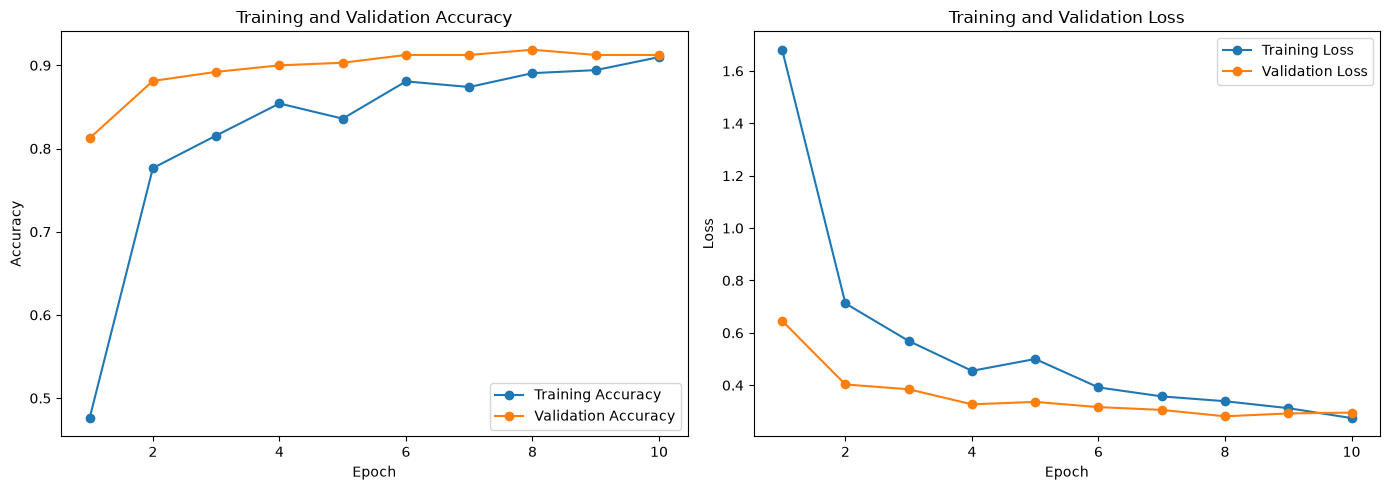

In [40]:
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, marker='o', label='Training Accuracy')
plt.plot(epochs_range, val_acc, marker='o', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, marker='o', label='Training Loss')
plt.plot(epochs_range, val_loss, marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 7. Model evaluation

In [25]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.2458
Test Accuracy: 0.9203


In [26]:
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test.to_numpy(), axis=1)

In [27]:
class_names = [
    'Abyssinian',
    'Bengal',
    'Birman',
    'Bombay',
    'British Shorthair',
    'Egyptian Mau',
    'american bulldog',
    'american pit bull terrier',
    'basset hound',
    'beagle',
    'boxer',
    'chihuahua',
    'english cocker spaniel',
    'english setter',
    'german shorthaired',
    'great pyrenees'
]

In [28]:
print(classification_report(y_true, y_pred, target_names=class_names))

                           precision    recall  f1-score   support

               Abyssinian       0.94      0.89      0.91        54
                   Bengal       0.89      0.89      0.89        36
                   Birman       1.00      1.00      1.00        38
                   Bombay       0.98      0.98      0.98        48
        British Shorthair       0.93      0.97      0.95        40
             Egyptian Mau       0.97      0.92      0.95        39
         american bulldog       0.85      0.91      0.88        43
american pit bull terrier       0.98      0.77      0.86        56
             basset hound       0.80      0.91      0.85        35
                   beagle       0.82      0.85      0.84        33
                    boxer       0.87      0.95      0.91        41
                chihuahua       0.98      0.93      0.95        44
   english cocker spaniel       0.91      0.94      0.92        32
           english setter       0.93      0.90      0.92     

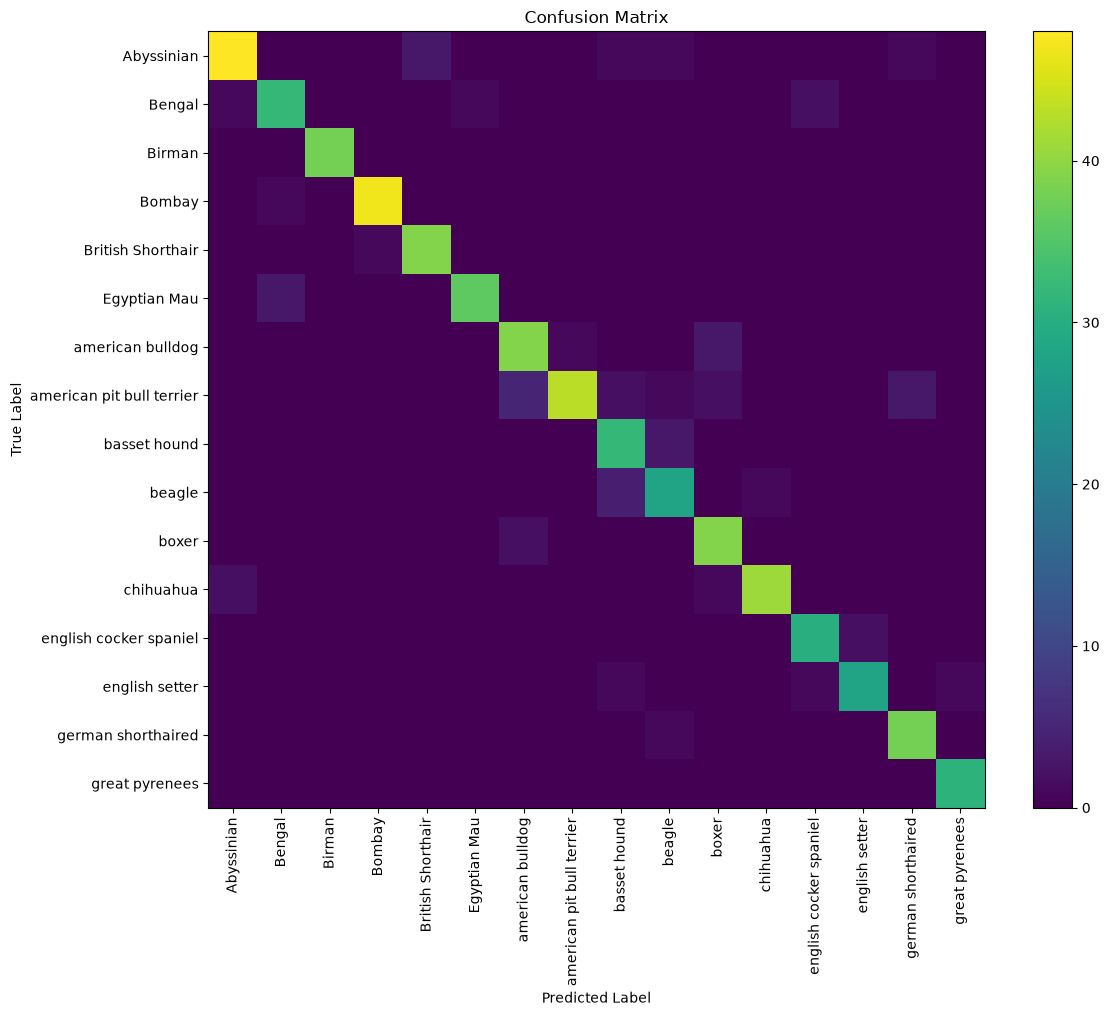

In [29]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
plt.imshow(cm)
plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=90)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# 8. Sample Predictions (Visualize)

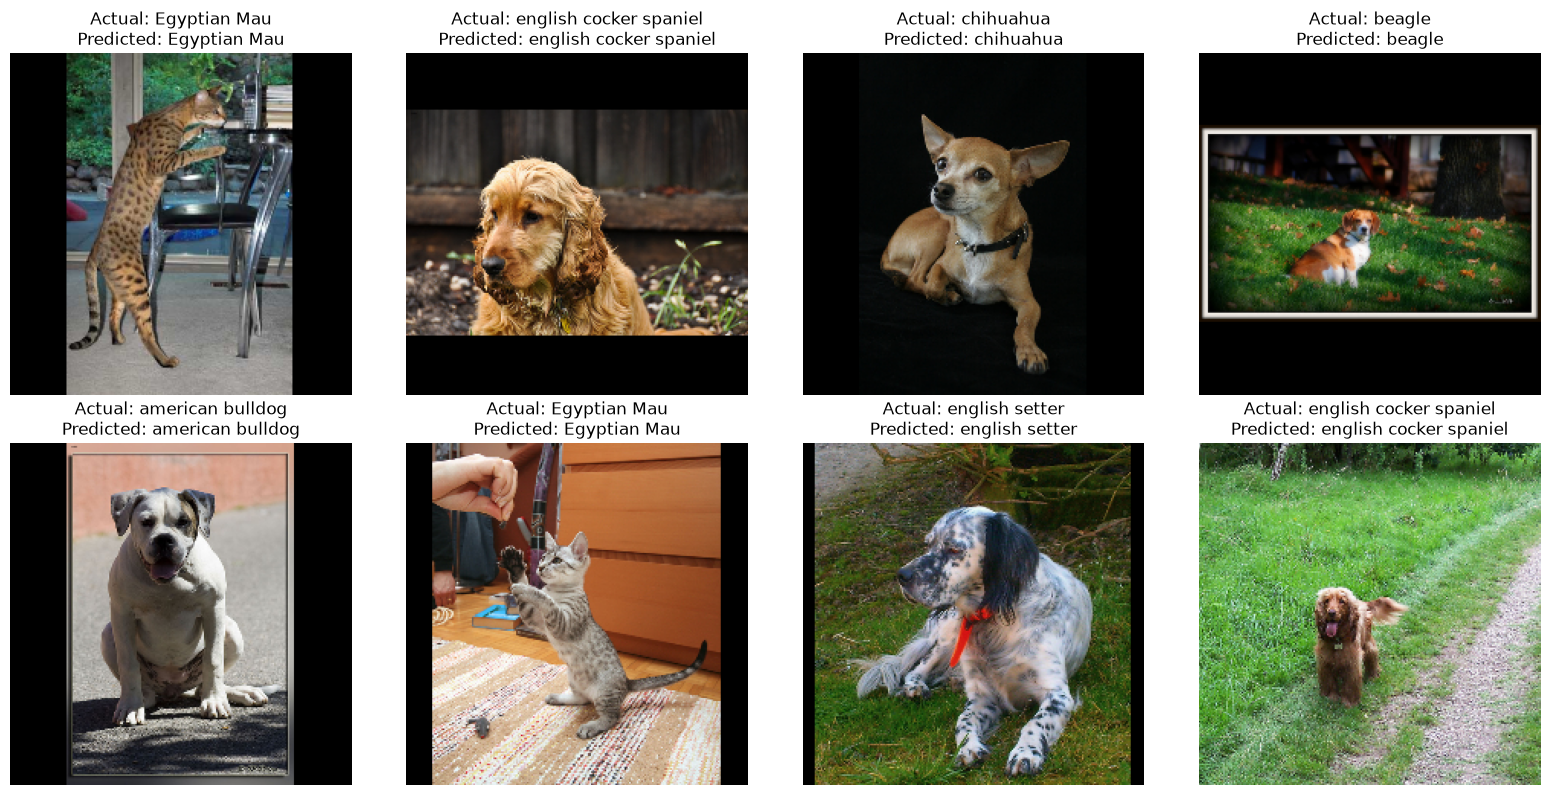

In [30]:
# Display sample predictions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, image_data, true_label, predicted_label in zip(axes.flat, X_test[:8], y_true[:8], y_pred[:8]):
    ax.imshow(image_data.astype(np.uint8))
    
    true_name = class_names[true_label]
    predicted_name = class_names[predicted_label]
    
    ax.set_title(f"Actual: {true_name}\nPredicted: {predicted_name}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# 9. Prediction Analysis

In [33]:
correct_indices = np.where(y_true == y_pred)[0]
incorrect_indices = np.where(y_true != y_pred)[0]

print(f"Correct predictions: {len(correct_indices)}")
print(f"Incorrect predictions: {len(incorrect_indices)}")

Correct predictions: 589
Incorrect predictions: 51


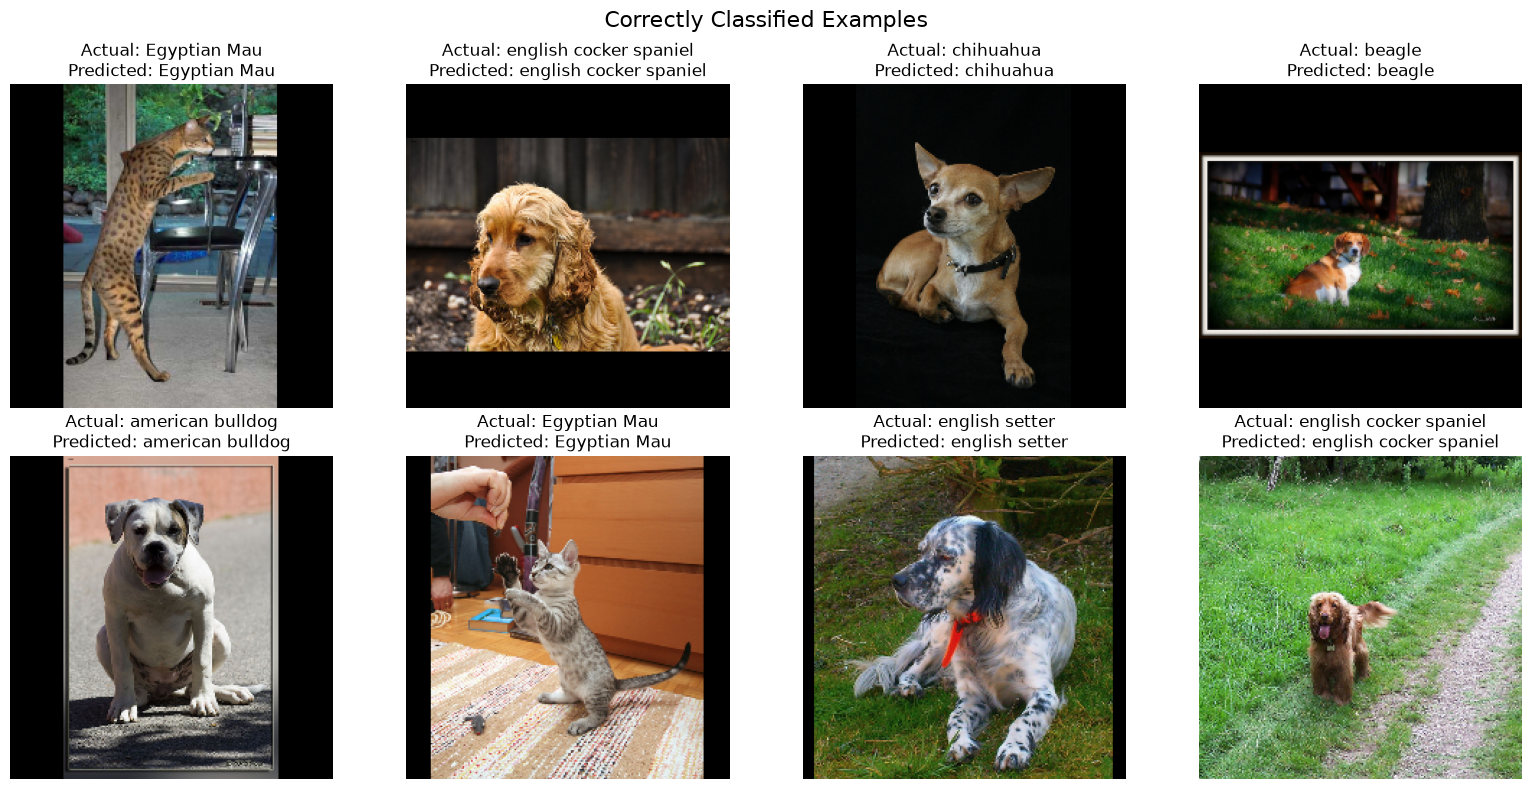

In [34]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, idx in zip(axes.flat, correct_indices[:8]):
    ax.imshow(X_test[idx].astype(np.uint8))

    true_name = class_names[y_true[idx]]
    predicted_name = class_names[y_pred[idx]]

    ax.set_title(f"Actual: {true_name}\nPredicted: {predicted_name}")
    ax.axis('off')

plt.suptitle("Correctly Classified Examples", fontsize=16)
plt.tight_layout()
plt.show()

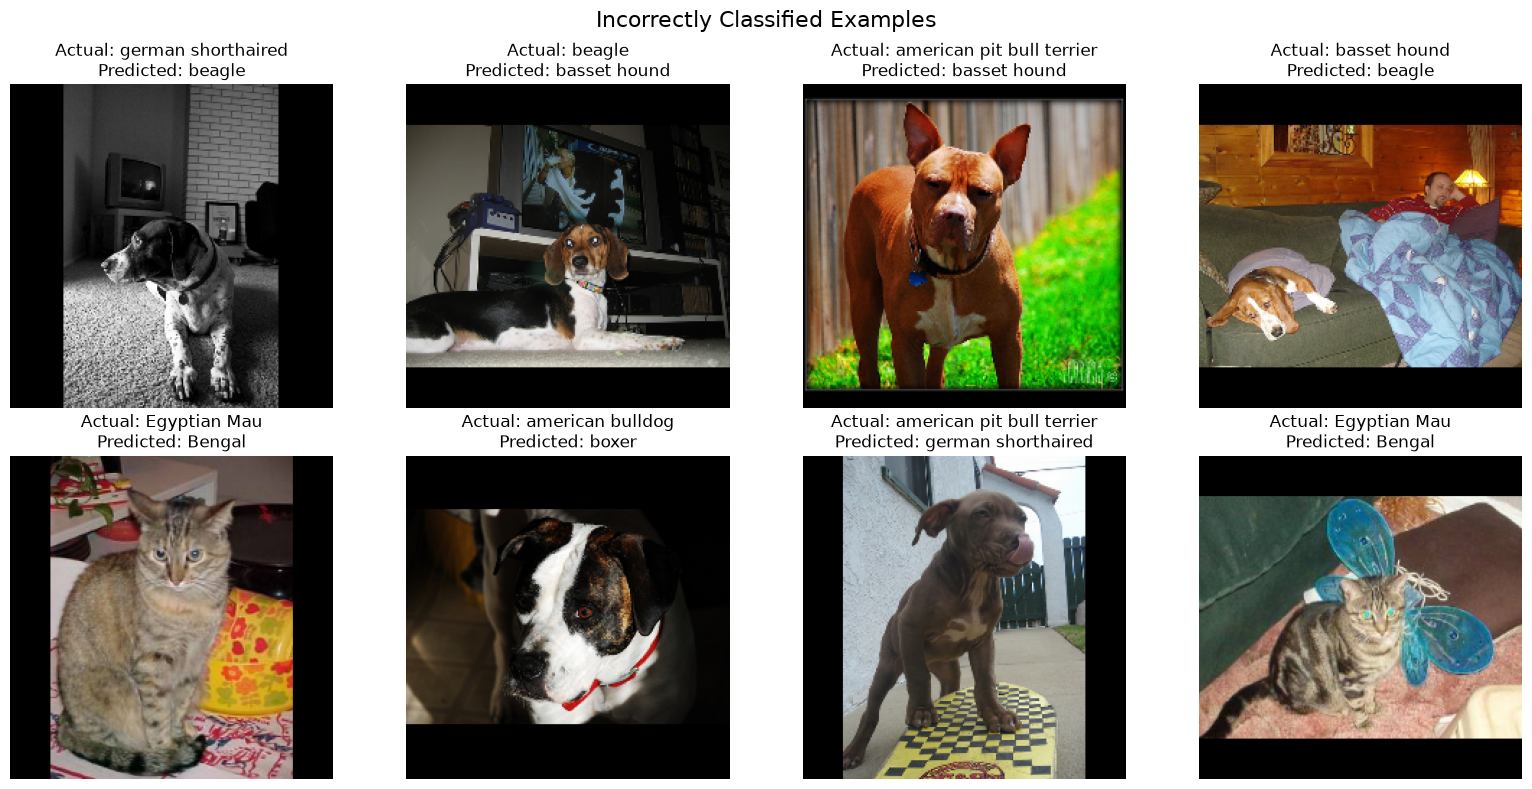

In [35]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, idx in zip(axes.flat, incorrect_indices[:8]):
    ax.imshow(X_test[idx].astype(np.uint8))

    true_name = class_names[y_true[idx]]
    predicted_name = class_names[y_pred[idx]]

    ax.set_title(f"Actual: {true_name}\nPredicted: {predicted_name}")
    ax.axis('off')

plt.suptitle("Incorrectly Classified Examples", fontsize=16)
plt.tight_layout()
plt.show()

# 10. Results and Conclusion

### Results

The transfer learning model achieved the following performance on the unseen test dataset:
Test Accuracy: 92.03%
Test Loss: 0.2458
Number of Classes: 16
Backbone: ResNet50 pretrained on ImageNet
Training Approach: Frozen pretrained feature extractor with a custom classification head
Training Epochs: 10

### Conclusion
This project demonstrates how transfer learning can be used to build an effective multiclass image classification model without training a deep convolutional neural network from scratch.
The pretrained ResNet50 backbone provides useful visual features, while data augmentation and a custom classification layer allow the model to adapt to the target pet categories.
The final model achieved 92.03% test accuracy on previously unseen images, demonstrating strong classification performance across the selected pet categories.
The visual predictions and confusion matrix also provide insight into the model's strengths and areas where classification can be challenging.
